In [10]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [26]:
# 累加器
# ------------------------
class Accumulator:
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# 计算精度
# ----------------------
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter):
    if isinstance(net, torch.nn.Module):
        net.eval()
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

# 单轮训练
# ----------------------
def train_epoch_ch3(net, train_iter, loss, updater):
    if isinstance(net, torch.nn.Module):
        net.train()
    metric = Accumulator(3)
    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    return metric[0] / metric[2], metric[1] / metric[2]


# 绘图器
# ----------------------
%matplotlib inline
class Animator:
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.'), figsize=(6, 4)):
        if legend is None:
            legend = []
        self.xlabel = xlabel
        self.ylabel = ylabel
        self.xlim = xlim
        self.ylim = ylim
        self.xscale = xscale
        self.yscale = yscale
        self.fmts = fmts
        self.legend = legend

        self.fig, self.ax = plt.subplots(1, 1, figsize=figsize)
        self.ax.set_xlabel(xlabel)
        self.ax.set_ylabel(ylabel)
        self.ax.set_xlim(xlim)
        self.ax.set_ylim(ylim)
        self.ax.set_xscale(xscale)
        self.ax.set_yscale(yscale)
        self.ax.legend(legend)
        # 存储曲线数据
        self.X, self.Y = [], []

    def add(self, x, y):
        # 统一处理y为列表
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        # 每条曲线共用同一个x值
        xs = [x] * n
        # 初始化存储容器
        if not self.X:
            self.X = [[] for _ in range(n)]
            self.Y = [[] for _ in range(n)]
        for i in range(n):
            xi = xs[i]
            yi = y[i]
            if xi is not None and yi is not None:
                self.X[i].append(xi)
                self.Y[i].append(yi)

    def show(self):
        self.ax.cla()
        for x_data, y_data, fmt, label in zip(self.X, self.Y, self.fmts, self.legend):
            self.ax.plot(x_data, y_data, fmt, label=label)
        self.ax.set_xlabel(self.xlabel)
        self.ax.set_ylabel(self.ylabel)
        self.ax.set_xlim(self.xlim)
        self.ax.set_ylim(self.ylim)
        self.ax.set_xscale(self.xscale)
        self.ax.set_yscale(self.yscale)
        self.ax.legend(fontsize=8, loc="upper right")
        plt.tight_layout()
        plt.show()


# 训练主函数
# ----------------------
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    animator = Animator(
        xlabel='epoch',
        xlim=[1, num_epochs],
        ylim=[0, 1.0],
        legend=['train loss', 'train acc', 'test acc'],
        fmts=('-', 'm--', 'g-.')
    )
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        print(f"epoch {epoch+1} | train loss {train_loss:.3f} | train acc {train_acc:.3f} | test acc {test_acc:.3f}")
        animator.add(epoch + 1, (train_loss, train_acc, test_acc))
    animator.show()

# 预测与画图
# ----------------------
def get_fashion_mnist_labels(labels):
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            ax.imshow(img.numpy())
        else:
            ax.imshow(img)
        ax.axis('off')
        if titles:
            ax.set_title(titles[i])
    plt.show()

def predict_ch3(net, test_iter, n=6):
    for X, y in test_iter:
        break
    trues = get_fashion_mnist_labels(y)
    preds = get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [f'True: {true}\nPred: {pred}' for true, pred in zip(trues, preds)]
    show_images(X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])

epoch 1 | train loss 0.785 | train acc 0.750 | test acc 0.787
epoch 2 | train loss 0.571 | train acc 0.813 | test acc 0.811
epoch 3 | train loss 0.524 | train acc 0.825 | test acc 0.806
epoch 4 | train loss 0.502 | train acc 0.831 | test acc 0.790
epoch 5 | train loss 0.485 | train acc 0.838 | test acc 0.807
epoch 6 | train loss 0.474 | train acc 0.840 | test acc 0.818
epoch 7 | train loss 0.465 | train acc 0.843 | test acc 0.827
epoch 8 | train loss 0.458 | train acc 0.845 | test acc 0.829
epoch 9 | train loss 0.452 | train acc 0.847 | test acc 0.833
epoch 10 | train loss 0.447 | train acc 0.847 | test acc 0.828


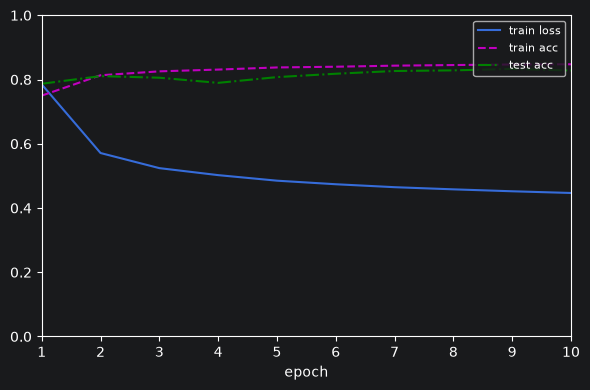

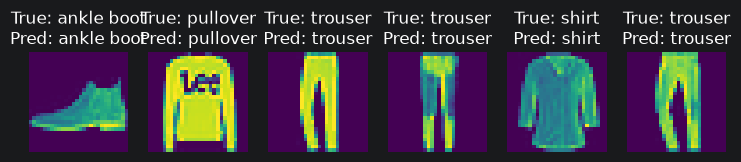

In [27]:
batch_size = 256
# 加载 FashionMNIST
train_dataset = datasets.FashionMNIST(root='./Data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.FashionMNIST(root='./Data', train=False, transform=transforms.ToTensor(), download=True)
train_iter = DataLoader(train_dataset, batch_size, shuffle=True)
test_iter = DataLoader(test_dataset, batch_size, shuffle=False)

num_inputs = 784
num_outputs = 10
W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)
    return X_exp / partition

def net(X):
    return softmax(X.reshape(-1, num_inputs) @ W + b)

def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y])

# 优化器
lr = 0.1
def updater(batch_size):
    with torch.no_grad():
        for param in [W, b]:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

# 训练
num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

# 预测
predict_ch3(net, test_iter)
